In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')

In [2]:
import asdf
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table, vstack, Column, hstack
from astropy import units as u
from astropy.visualization import simple_norm

In [3]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
import artpop
import rosesim
from rosesim.display import show_image_wcs
from rosesim.rose import RomanGalaxy, RomanSky, RomanSymphony
rng = np.random.RandomState(100)
DATA_PATH = rosesim.DATA_PATH
SYMPHONY_PATH = '/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/symphony-hr/'
sys.path.append('/home/jiaxuanl/Research/Roman_Cycle1/')

In [4]:
from astropy.table import Table, vstack, hstack
import h5py
import pandas as pd
from tqdm import trange
from ripples.utils import read_h5_into_df

## We already have a sky object. Let's just load the symphony mocks, put it at 8 Mpc, and see how that look like

In [5]:
gal = RomanSymphony(prefix='symphony_test', data_dir=DATA_PATH)

In [7]:
# we use empty sky for now
obs_ra = 150# .#1049
obs_dec = 0 #2.2741
# obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

gal_kwargs = {'distance': 3 * u.Mpc}

dist = gal_kwargs['distance'].to(u.Mpc).value
dmod = 5 * np.log10(dist) + 25

abs_mag_lim = 2
mag_lim = dmod + abs_mag_lim
print('mag lim', mag_lim)

mag lim 29.385606273598313


In [8]:
gal.kwargs = gal_kwargs

In [11]:
filt = 'F106'
t_exp = 642
# t_exp = 10272
# t_exp = 5136
gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky_test/{filt}_{t_exp}s.asdf')
# gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf')
gal.roman_wcs = gal.sky_dm.meta.wcs

Loaded background from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky_test/F106_642s.asdf


In [31]:
# src = Table.read(SYMPHONY_PATH + '/symphony-hr_halo023_roman_2mag.csv')
# src = Table.read(SYMPHONY_PATH + '/symphony-hr_halo023_roman_3mag.csv')
src = Table.read(SYMPHONY_PATH + '/symphony-hr_halo023_roman_4mag_F087.csv')

In [32]:
src[:3]

col0,age,eep,feh,logL,logTe,logg,mass,pid,vx,vy,vz,x,y,z,abs_F062mag,abs_F087mag,abs_F106mag,abs_F129mag,abs_F158mag,abs_F184mag,abs_F146mag,abs_F213mag
int64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,10.125061,2,-2.3544164,0.61093175,3.786806,3.7907917,0.76678574,472,65.11895,153.95615,-162.21912,17.721354,3.8787527,3.519553,3.2296417,3.1281202,3.1264048,3.3339176,3.3089027,3.4888473,3.3882132,3.7578983
1,10.127186,1,-3.1270695,-0.023618484,3.7951195,4.4432616,0.70769894,472,-46.878895,68.098785,96.58571,-14.335212,-1.2442958,6.1666055,4.874998,4.7874875,4.7954135,5.0104766,4.994831,5.1805058,5.0666823,5.4486485
2,10.126435,1,-2.4361773,0.03611309,3.7993314,4.405365,0.7162589,472,-45.94979,72.830376,-36.63873,7.2015176,5.8615494,75.48716,4.72904,4.6526084,4.6651354,4.8838916,4.8734922,5.061629,4.9413285,5.331002


In [72]:
r_proj = np.sqrt(src['x']**2 + src['y']**2)
# flag = (r_proj < 17) & (r_proj > 15)
flag = (r_proj < 57) & (r_proj > 55)
temp = src[flag]

In [73]:
theta = np.rad2deg(np.arctan2(temp['y'], temp['x']))

In [74]:
flag = np.abs(theta) < 30

In [75]:
len(temp)

41680

In [76]:
dist = 785 # kpc, M31
dmod = 5 * np.log10(dist / 1e3) + 25
area = np.pi * (np.rad2deg(57 / dist)**2 - np.rad2deg(55 / dist)**2) # sq deg at 

In [77]:
len(temp[flag]) / (area * (30/360)) / 1e5, len(temp) / (area) / 1e5

(np.float64(0.7251727400987433), np.float64(0.11117928274595608))

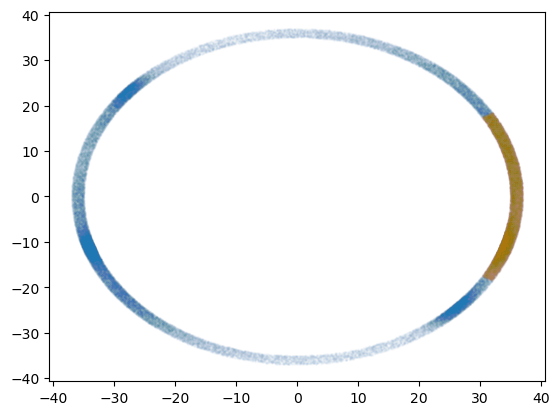

In [69]:
plt.scatter(temp['x'], temp['y'], s=1, alpha=0.01)
plt.scatter(temp['x'][flag], temp['y'][flag], s=1, alpha=0.01)

In [38]:
28.54 - dmod

np.float64(4.065651716273738)

In [39]:
np.sum(temp['abs_F087mag'] < 4.)

np.int64(81554)

(-1.0, 1.5)

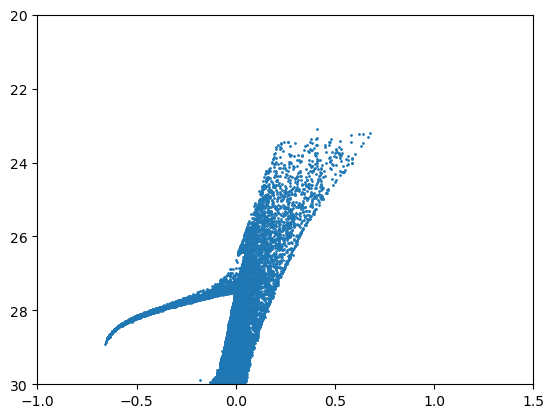

In [24]:
plt.scatter(temp['abs_F106mag'] - temp['abs_F158mag'], temp['abs_F106mag'] + dmod, s=1)

# plt.axhline(-5.4 + dmod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')
plt.ylim(30, 20)
plt.xlim(-1, 1.5)

In [13]:
src.colnames

['col0',
 'age',
 'eep',
 'feh',
 'logL',
 'logTe',
 'logg',
 'mass',
 'pid',
 'vx',
 'vy',
 'vz',
 'x',
 'y',
 'z',
 'abs_F062mag',
 'abs_F087mag',
 'abs_F106mag',
 'abs_F129mag',
 'abs_F158mag',
 'abs_F184mag',
 'abs_F146mag',
 'abs_F213mag']

In [10]:
temp = src[src['abs_F158mag'] < 0]
#[src['feh'] < -2]

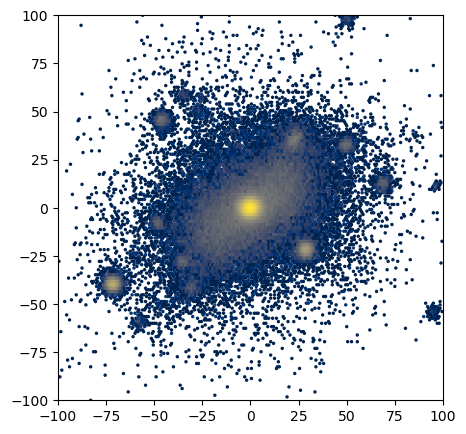

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
_x = 100
hb = ax.hexbin(
    temp['x'], temp['z'],
    gridsize=200,
    extent=[-_x, _x, -_x, _x],
    bins='log',
    cmap='cividis'
)
# plt.colorbar(hb, ax=ax, label='log$_{10}$(Counts)')
ax.set_xlim(-_x, _x)
ax.set_ylim(-_x, _x)
ax.set_aspect('equal')

Text(0, 0.5, 'Y [kpc]')

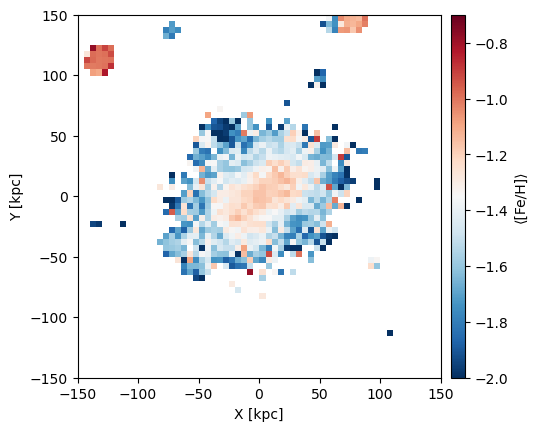

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from mpl_toolkits.axes_grid1 import make_axes_locatable

_x = 150
bins = 60

stat, xedges, yedges, _ = binned_statistic_2d(
    temp['x'],
    temp['z'],
    temp['feh'],
    statistic='median',
    bins=bins,
    range=[[-_x, _x], [-_x, _x]]
)
counts, _, _, _ = binned_statistic_2d(
    temp['x'],
    temp['z'],
    None,
    statistic='count',
    bins=bins,
    range=[[-_x, _x], [-_x, _x]]
)

stat[counts < 4] = np.nan

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(
    stat.T,
    origin='lower',
    extent=[-_x, _x, -_x, _x],
    cmap='RdBu_r',   # metallicity-friendly
    aspect='equal',
    vmin=-2, vmax=-0.7
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.1)

plt.colorbar(im, cax=cax, label='⟨[Fe/H]⟩')

ax.set_xlim(-_x, _x)
ax.set_ylim(-_x, _x)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')

In [13]:
delta_x = np.rad2deg((src['x']) / (dist * 1e3))
delta_y = np.rad2deg((src['z']) / (dist * 1e3))
delta_x -= np.median(delta_x)
delta_y -= np.median(delta_y)
delta_ra = delta_x / np.cos(np.deg2rad(obs_dec))
delta_dec = delta_y

src['ra'], src['dec'] = obs_ra + delta_ra, obs_dec + delta_dec
flag = gal.roman_wcs.in_image(SkyCoord(src['ra'], src['dec'], unit='deg'))
gal.load_src(src[flag], ra=obs_ra, dec=obs_dec)

In [14]:
np.sum(flag)

np.int64(405719)

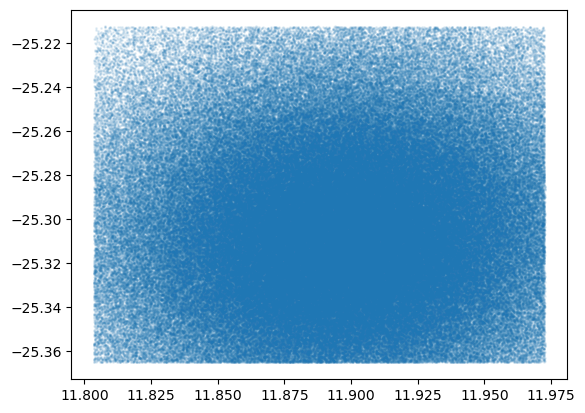

In [15]:
plt.scatter(gal.src['ra'], gal.src['dec'], s=1, alpha=0.1)

In [24]:
import kuaizi
kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=18, figsize=(7, 5), dpi=90)

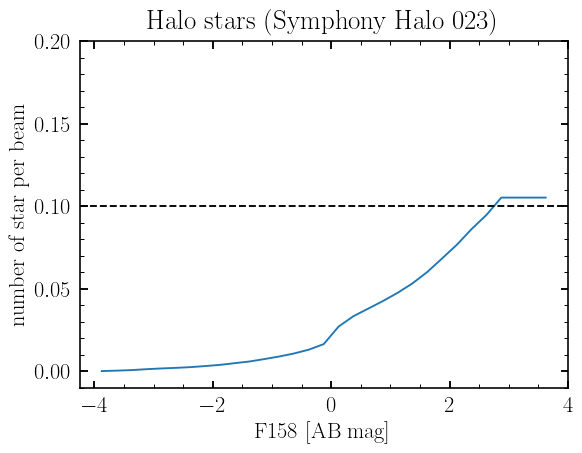

In [26]:
A_beam = 0.11**2
# calculate the source density within r_e
_r = np.sqrt((gal.src['ra'] - 11.90)**2 + (gal.src['dec'] - -25.32)**2)
flag = (_r < 0.01)
area = (0.01 * 3600)**2
n_star, bins = np.histogram(gal.src['abs_F158mag'][flag], bins=np.arange(-4, 4, 0.25))
n_star = np.cumsum(n_star)
cen = (bins[1:] + bins[:-1]) / 2
plt.plot(cen, (n_star / area * A_beam))

plt.ylim(-0.01, 0.2)
plt.axhline(0.1, color='k', ls='--')
plt.xlabel('F158 [AB mag]')
plt.ylabel('number of star per beam')
plt.title('Halo stars (Symphony Halo 023)')
plt.legend()

In [205]:
mag_table = gal.src.copy()
for filt in gal.filters:
    mag_table[filt] = mag_table[f'abs_{filt}mag'] + dmod
for filt in gal.filters:
    mag_table[filt] = 10**(-0.4 * mag_table[filt]) # to maggies

pts_table = Table()
pts_table['type'] = Column(data=['PSF']*len(mag_table))
pts_table = hstack([pts_table, mag_table])
full_table = pts_table
# flag = (full_table['abs_F106mag'] - full_table['abs_F158mag']) > 0.75
# full_table = full_table[flag]
full_table.write(f'./temp/full_table.ecsv', format='ascii.ecsv', overwrite=True)
gal.obj_cat = full_table
print('Catalogue generated.')

Catalogue generated.


In [206]:
len(full_table)

405724

(-1.0, 1.5)

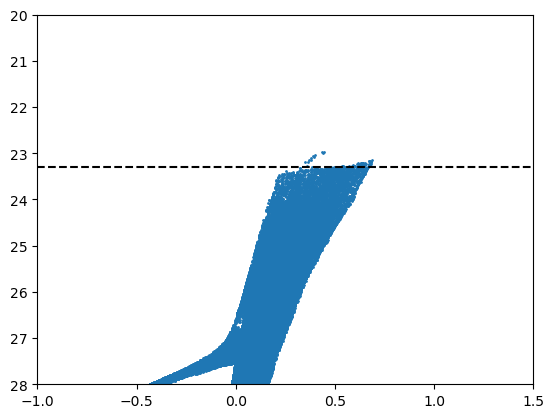

In [166]:
plt.scatter(gal.obj_cat['abs_F106mag'] - gal.obj_cat['abs_F158mag'], gal.obj_cat['abs_F106mag'] + dmod, s=1)

plt.axhline(-5.4 + dmod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')
plt.ylim(28, 20)
plt.xlim(-1, 1.5)

In [420]:
# pts_table.write(f'./temp/pts_table.ecsv', format='ascii.ecsv', overwrite=True)

In [208]:
for filt in ['F106', 'F129', 'F158']:
    gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf')
    # gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky_test/{filt}_{t_exp}s.asdf')
    gal.observe(exptimes=t_exp, psftype='epsf', fastpointsources=True)
    gal.dm.save(f'./ngc253_{filt}_{t_exp}s_epsf_fast.asdf')

Loaded background from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F106_5136s.asdf


2026-02-07 00:44:23 INFO     Setting pixscale to match default.


2026-02-07 00:44:23 WARNING  wcs is None; unlikely to get orientation of PSF correct.


2026-02-07 00:44:23 INFO     Creating PSF from CRDS reference type epsf


2026-02-07 00:44:23 WARNING  wcs is None; unlikely to get orientation of PSF correct.


...

2026-02-07 00:46:46 INFO     Creating PSF from CRDS reference type epsf


2026-02-07 00:46:48 INFO     Adding 405724 sources to image...


2026-02-07 00:46:55 WARNING  Adding noise to each star individually.


2026-02-07 00:47:51 INFO     Rendered 405724 point sources in 56 seconds


2026-02-07 00:47:51 INFO     Rendered 405724 total sources in 56.1 seconds


In [45]:
from galsim import roman
import warnings
from copy import deepcopy
import astrocut
from astrocut import get_center_pixel, ASDFCutout
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

In [184]:
asdf_cutout = ASDFCutout("./F106_642s_galsim_fast.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)
img_galsim_fast = asdf_cutout.cutouts[0].data - 0.314

asdf_cutout = ASDFCutout("./F106_642s_galsim_slow.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)
img_galsim_slow = asdf_cutout.cutouts[0].data - 0.314

In [13]:
# dm = rosesim.utils.read_L3_asdf('./F158_642s.asdf')
# psf = dm.psf

In [45]:
dm = rosesim.read_L3_asdf('./F106_642s.asdf')

In [193]:
rosesim.utils.asdf_to_fits(dm, './test.fits', subtract_bkg=True)

Successfully wrote FITS file: ./test.fits


In [162]:
rosesim.asdf_to_fits(gal.dm, f'{filt}_642s.fits', subtract_bkg=True)

Successfully wrote FITS file: F158_642s.fits


# Visualize

In [202]:
# cen_ra, cen_dec = 11.8880580, -25.2888000 

In [205]:
SkyCoord(obs_ra, obs_dec, unit='deg')

<SkyCoord (ICRS): (ra, dec) in deg
    (150.1049, 2.2741)>

In [39]:
from astropy.visualization import make_lupton_rgb
import sep

zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


25.265227862373404


In [40]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/symphony_test'

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/symphony_test'

In [209]:
prefix = 'ufd_1e6_25Mpc_1.0Gyr'
# prefix = 'dw_1e5.5_20Mpc_1.0Gyr'
prefix = 'dw_1e7.0_35Mpc_0.4Gyr'
# prefix = 'ufd_1e3_2Mpc_0.4Gyr'
# prefix = 'dw_1e5.5_2Mpc_2.0Gyr'
prefix = 'dw_1e5.5_2Mpc_age9.6_feh-1.5'
# prefix = 'dw_1e6.0_2Mpc_age9.6_feh-1.5'
# prefix = 'dw_1e4.5_3.0Mpc_age9.6_feh-2.0'
# prefix = 'dw_1e6.0_10.0Mpc_age9.6_feh-2.0'
# prefix = 'dw_1e6.0_2.0Mpc_age9.6_feh-2.0'
prefix = 'dw_1e5.5_2.0Mpc_age9.6_feh-1.5'
prefix = 'symphony_test'

In [210]:
# obs_ra, obs_dec = 150.0763360, 2.3118682

In [211]:
cen_ra, cen_dec = obs_ra, obs_dec
import sep

In [213]:
filters = ['F106', 'F129', 'F158']
imgs = []
t_exp = 10272
t_exp = 5136
# t_exp = 642
for filt in filters:
    file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_{t_exp}s_epsf_fast.asdf", 
    file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/ngc253_{filt}_{t_exp}s_epsf_fast.asdf", 
    # file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf", 
    # file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal/{filt}_642s.asdf", 
    asdf_cutout = ASDFCutout(file,
                             SkyCoord(cen_ra, cen_dec, unit='deg'), 5001) # 5001
    # SkyCoord(obs_ra, obs_dec, unit='deg'), 4069) # 5001
    
    hdu = asdf_cutout.fits_cutouts[0]
    img = hdu[0].data
    bkg = sep.Background(img, bw=256, bh=256)
    hdu[0].data -= bkg.globalback
    hdu.writeto(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_642s_cutout.fits', overwrite=True)

    img *= 10**(0.4 * (27 - zp))
    # imgs.append(img[250:1250, :])
    imgs.append(img[:, :])

/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


In [214]:
import rosesim

In [ ]:
# rgb = make_lupton_rgb(0.95 * imgs[2], 1.15 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=0.2, Q=3)
rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=0.5, Q=1)
# fig, ax = plt.subplots(figsize=(10, 10))
fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb) #, origin='lower')
plt.axis('off')

# plt.text(wid - 0.2 * wid, +5, filters[filt_idx[0]], 
         # fontsize=20, color='deepskyblue', va='center', ha='center')
# plt.text(wid, +5, filters[filt_idx[1]], 
         # fontsize=20, color='limegreen', va='center', ha='center')
# plt.text(wid + 0.2 * wid, +5, filters[filt_idx[2]], 
         # fontsize=20, color='orangered', va='center', ha='center')
# title = prefix
# plt.title(title, fontsize=20)

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True, pad_inches=0)
# plt.close()

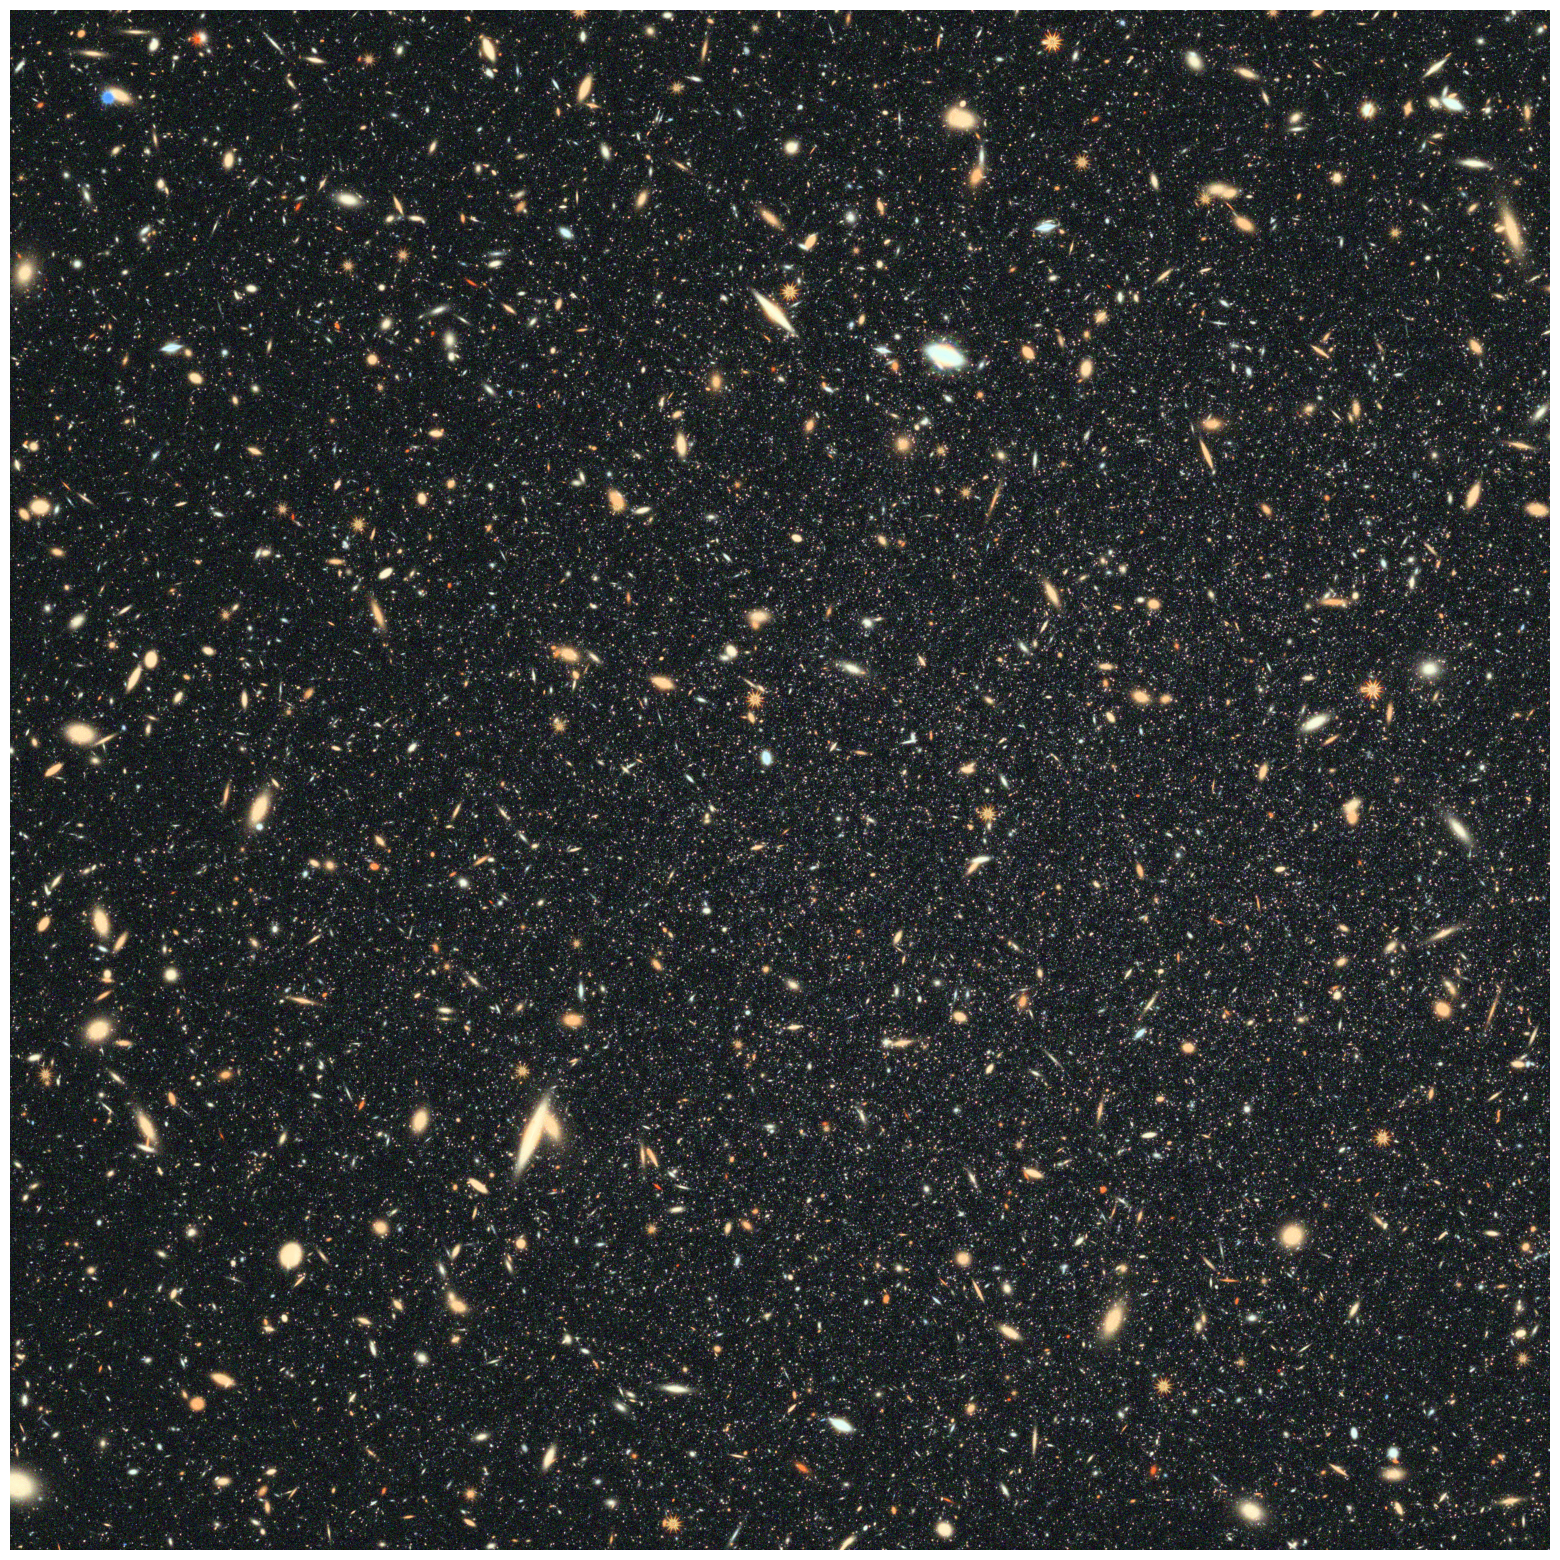

In [215]:
rgb = make_lupton_rgb(0.95 * imgs[2], 1.15 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=0.2, Q=3)
# rgb = make_lupton_rgb(1 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=0.5, Q=1)
fig, ax = plt.subplots(figsize=(20, 20))
# fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb[:-1000, :-1000], origin='lower')
plt.axis('off')

# plt.text(wid - 0.2 * wid, +5, filters[filt_idx[0]], 
         # fontsize=20, color='deepskyblue', va='center', ha='center')
# plt.text(wid, +5, filters[filt_idx[1]], 
         # fontsize=20, color='limegreen', va='center', ha='center')
# plt.text(wid + 0.2 * wid, +5, filters[filt_idx[2]], 
         # fontsize=20, color='orangered', va='center', ha='center')
# title = prefix
# plt.title(title, fontsize=20)

plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True, pad_inches=0)
# plt.close()